In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from scipy.integrate import quad
import itertools
from collections import Counter
np.random.seed(42)

# Завдання 1
Урна: 12 куль (7 синіх, 5 червоних). Витягуємо 6. $\xi$ — кількість червоних. $M = \{\xi = 5\}$.

$\xi \sim \text{Hypergeometric}(N=12,\, K=5,\, n=6)$

## I. Теоретичні викладки

$$P(\xi=k) = \frac{\binom{5}{k}\binom{7}{6-k}}{\binom{12}{6}}, \quad k=0,1,2,3,4,5$$

$$P(M) = P(\xi=5) = \frac{\binom{5}{5}\binom{7}{1}}{\binom{12}{6}} = \frac{7}{924}$$

$$\mathbb{E}[\xi] = n\frac{K}{N} = 6\cdot\frac{5}{12} = \frac{5}{2}, \quad
\mathbf{Var}[\xi] = n\frac{K}{N}\frac{N-K}{N}\frac{N-n}{N-1} = \frac{35}{44}$$

In [2]:
N, K, n = 12, 5, 6
ks = np.arange(0, 6)
pmf = np.array([comb(K,k,exact=True)*comb(N-K,n-k,exact=True)/comb(N,n,exact=True) for k in ks])

P_M    = pmf[5]
E_xi   = np.sum(ks * pmf)
Var_xi = np.sum(ks**2 * pmf) - E_xi**2

print("k  | P(ξ=k)")
for k, p in zip(ks, pmf):
    print(f"{k}  | {p:.6f}")
print(f"\nP(M)=P(ξ=5) = {P_M:.6f} = 7/924  (теор. 7/924 = {7/924:.6f})")
print(f"E[ξ]  = {E_xi:.4f}  (теор. 5/2 = {5/2})")
print(f"Var[ξ]= {Var_xi:.4f}  (теор. 35/44 = {35/44:.4f})")

k  | P(ξ=k)
0  | 0.007576
1  | 0.113636
2  | 0.378788
3  | 0.378788
4  | 0.113636
5  | 0.007576

P(M)=P(ξ=5) = 0.007576 = 7/924  (теор. 7/924 = 0.007576)
E[ξ]  = 2.5000  (теор. 5/2 = 2.5)
Var[ξ]= 0.7955  (теор. 35/44 = 0.7955)


## II. Повний перебір

## III. Симуляції

In [3]:
print(f"{'B':>8} | {'P(M)':>10} | {'E[ξ]':>8} | {'Var[ξ]':>8}")
print("-"*45)
for B in [100, 1000, 10000]:
    s = np.random.hypergeometric(K, N-K, n, size=B)
    pm = np.mean(s == 5)
    print(f"{B:>8} | {pm:>10.6f} | {np.mean(s):>8.4f} | {np.var(s):>8.4f}")
print(f"{'Теорія':>8} | {P_M:>10.6f} | {E_xi:>8.4f} | {Var_xi:>8.4f}")
print("\nНаближення покращуються зі збільшенням кількості симуляцій.")

       B |       P(M) |     E[ξ] |   Var[ξ]
---------------------------------------------
     100 |   0.020000 |   2.5900 |   0.7819
    1000 |   0.004000 |   2.4810 |   0.7496
   10000 |   0.008400 |   2.5061 |   0.7942
  Теорія |   0.007576 |   2.5000 |   0.7955

Наближення покращуються зі збільшенням кількості симуляцій.


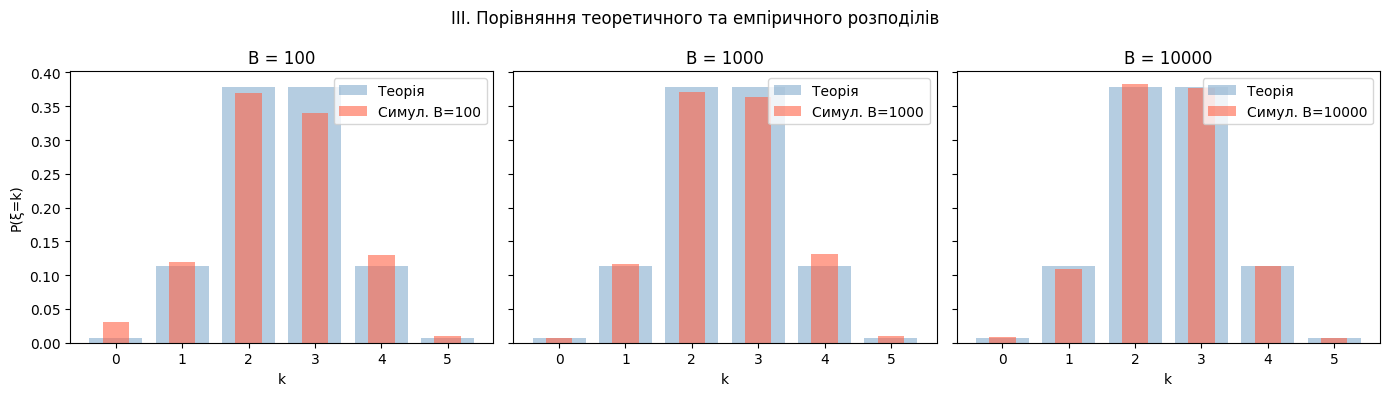

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, B in zip(axes, [100, 1000, 10000]):
    s = np.random.hypergeometric(K, N-K, n, size=B)
    cnts = Counter(s)
    ax.bar(ks, pmf, alpha=0.4, label='Теорія', color='steelblue')
    ax.bar(ks, [cnts.get(k,0)/B for k in ks], alpha=0.6,
           label=f'Симул. B={B}', color='tomato', width=0.4)
    ax.set_title(f'B = {B}'); ax.set_xlabel('k'); ax.legend()
axes[0].set_ylabel('P(ξ=k)')
plt.suptitle('III. Порівняння теоретичного та емпіричного розподілів')
plt.tight_layout(); plt.show()

---
# Завдання 2

$$f(t) = \frac{C}{t^2}\cdot\mathbf{1}_{(-\infty,\,-1)}(t)$$

## I. Теоретичні викладки

**1. Стала C:**
$$\int_{-\infty}^{-1}\frac{C}{t^2}\,dt = C\left[-\frac{1}{t}\right]_{-\infty}^{-1} = C\cdot 1 = 1 \implies \boxed{C=1}$$

**2. Функція розподілу:**
$$F(t)=\int_{-\infty}^{t}f(s)\,ds =
\begin{cases}-\dfrac{1}{t}, & t\leq -1,\\[6pt] 1, & t > -1\end{cases}$$

**Моменти:**
$$\mathbb{E}[\xi]=\int_{-\infty}^{-1}\frac{t}{t^2}\,dt=\int_{-\infty}^{-1}\frac{1}{t}\,dt = -\infty
\quad\Rightarrow\quad \mathbb{E}[\xi]=-\infty,\;\mathbf{Var}[\xi]\text{ не існує.}$$

∫f(t)dt = 1.000000, error = 1.11e-14  (має бути 1)

Чисельно E[ξ] ≈ -18.42  (→ -∞, момент не існує)
Чисельно E[ξ²] ≈ 99999999.00  (→ +∞, Var[ξ] не існує)


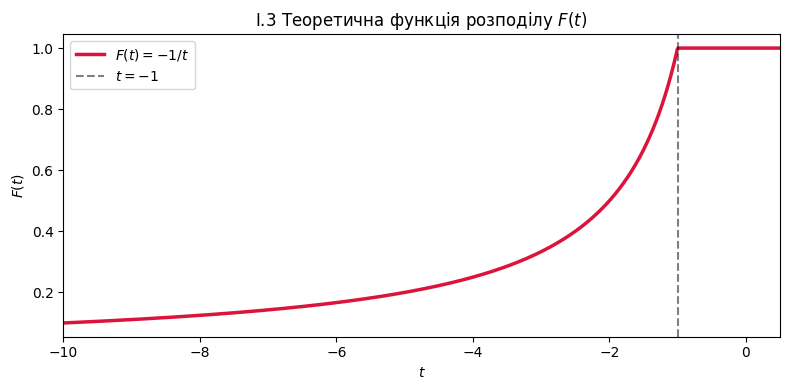

In [5]:
# I.1 Перевірка C=1
result, err = quad(lambda t: 1/t**2, -np.inf, -1)
print(f"∫f(t)dt = {result:.6f}, error = {err:.2e}  (має бути 1)")

# I.3 Функції щільності та розподілу
def f(t: float) -> float:
    return np.where(t < -1, 1/t**2, 0.0)

def F(t: float) -> float:
    return np.where(t <= -1, -1/t, 1.0)

# I.4 Функція для моментів через чисельне інтегрування
def moment(k: int) -> float:
    val, _ = quad(lambda t: t**k / t**2, -1e8, -1)
    return val

print(f"\nЧисельно E[ξ] ≈ {moment(1):.2f}  (→ -∞, момент не існує)")
print(f"Чисельно E[ξ²] ≈ {moment(2):.2f}  (→ +∞, Var[ξ] не існує)")

# Графік F(t)  — I.3
t_vals = np.linspace(-10, 0.5, 1000)
plt.figure(figsize=(8, 4))
plt.plot(t_vals, F(t_vals), color='crimson', linewidth=2.5, label='$F(t) = -1/t$')
plt.axvline(-1, color='black', linestyle='--', alpha=0.5, label='$t=-1$')
plt.title('I.3 Теоретична функція розподілу $F(t)$')
plt.xlabel('$t$'); plt.ylabel('$F(t)$'); plt.legend()
plt.xlim(-10, 0.5); plt.tight_layout(); plt.show()

## II. Симуляції

**Квантильне перетворення:** $F(t)=p \Rightarrow t=-1/p$, тобто $F^{-1}(p)=-1/p$.

**Метод проріджування:**
Робимо заміну $W = \ln(-T)$, тоді $W > 0$ і
$$f_W(w) = f_T(-e^w)\cdot e^w = e^{-2w}\cdot e^w = e^{-w} \sim \mathrm{Exp}(1).$$
Отже, достатньо отримати точні вибірки $W\sim\mathrm{Exp}(1)$ і покласти $T=-e^W$.
Для демонстрації методу проріджування використовуємо $g(w)=\lambda e^{-\lambda w}$, $\lambda=0.5$:
$$\frac{f_W(w)}{C\cdot g(w)} = \frac{e^{-w}}{2\cdot 0.5\cdot e^{-0.5w}} = e^{-0.5w}\leq 1,\quad C=\frac{1}{\lambda}=2.$$
Генерація: $W\sim\mathrm{Exp}(0.5)$, приймаємо якщо $U_2 < e^{-0.5W}$, потім $T=-e^W$.

Обидва методи відтворюють розподіл. Для наступних пунктів використовується **квантильне перетворення**.

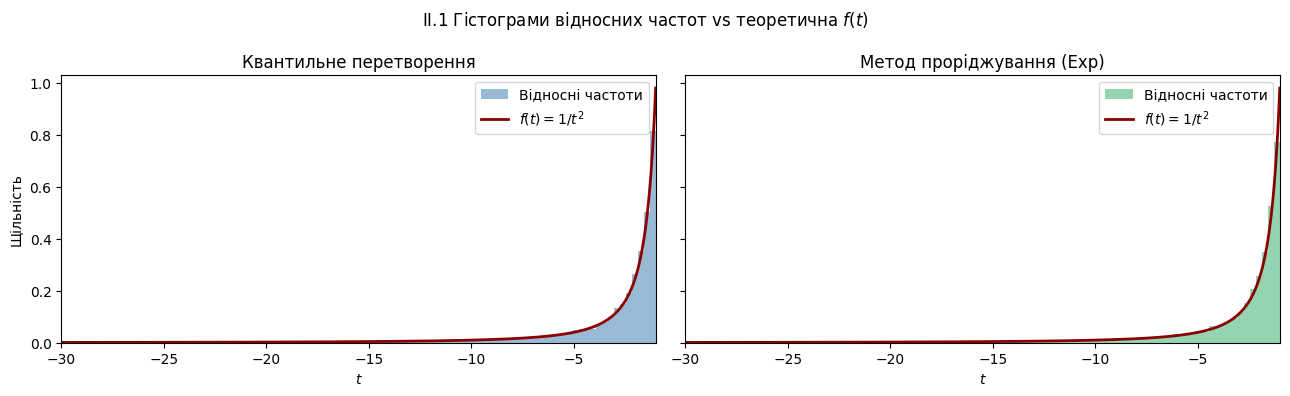

In [6]:
def generate_quantile(B):
    U = np.random.uniform(0, 1, B)
    return -1.0 / U

def generate_rejection(B):
    lam = 0.5  
    C = 1.0 / lam  
    samples_w = []
    while len(samples_w) < B:
        W  = np.random.exponential(1.0 / lam, B) 
        U2 = np.random.uniform(0, 1, B)
        acc = W[U2 < np.exp(-(1 - lam) * W)]
        samples_w.extend(acc.tolist())
    W_accepted = np.array(samples_w[:B])
    return -np.exp(W_accepted)  

B_plot = 10000
xi_q = generate_quantile(B_plot)
xi_r = generate_rejection(B_plot)

# II.1 Гістограми
t_plot = np.linspace(-30, -1.01, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, xi, title, color in zip(axes,
        [xi_q, xi_r],
        ['Квантильне перетворення', 'Метод проріджування (Exp)'],
        ['steelblue', 'mediumseagreen']):
    ax.hist(xi, bins=100, density=True, color=color, alpha=0.55,
            range=(-30, -1), label='Відносні частоти')
    ax.plot(t_plot, 1/t_plot**2, color='darkred', linewidth=2, label='$f(t)=1/t^2$')
    ax.set_title(title); ax.set_xlabel('$t$'); ax.legend(); ax.set_xlim(-30, -1)
axes[0].set_ylabel('Щільність')
plt.suptitle('II.1 Гістограми відносних частот vs теоретична $f(t)$')
plt.tight_layout(); plt.show()

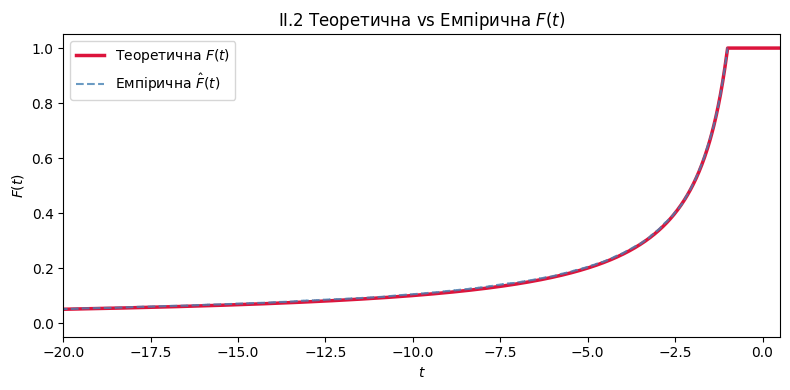

In [7]:
# II.2 Теоретична vs емпірична F(t)
xi_best = generate_quantile(B_plot)
t_vals2 = np.linspace(-20, 0.5, 1000)

plt.figure(figsize=(8, 4))
plt.plot(t_vals2, F(t_vals2), color='crimson', linewidth=2.5, label='Теоретична $F(t)$')
sorted_xi = np.sort(xi_best)
ecdf = np.arange(1, B_plot+1) / B_plot
plt.step(sorted_xi, ecdf, color='steelblue', linewidth=1.5,
         linestyle='--', label='Емпірична $\\hat{F}(t)$', alpha=0.8)
plt.title('II.2 Теоретична vs Емпірична $F(t)$')
plt.xlabel('$t$'); plt.ylabel('$F(t)$'); plt.xlim(-20, 0.5); plt.legend()
plt.tight_layout(); plt.show()

In [8]:
# II.3 E[ξ], Var[ξ] за симуляціями
print(f"{'B':>8} | {'E[ξ] (симул.)':>16} | {'Var[ξ] (симул.)':>18}")
print("-"*50)
for B in [100, 1000, 10000]:
    s = generate_quantile(B)
    print(f"{B:>8} | {np.mean(s):>16.2f} | {np.var(s):>18.2f}")
print("\nE[ξ]→ -∞, Var[ξ] не існує: наближення розбігаються.")

# II.4 F(t) та E[ξ] через чисельне інтегрування (реалізація пп. I.3 та I.4)
print("\n--- II.4: Чисельне інтегрування ---")

# F(t) через quad (п. I.3)
def F_quad(t: float) -> float:
    val, _ = quad(lambda s: 1/s**2, -np.inf, min(t, -1.0))
    # min(..., 1.0) захищає від чисельних похибок > 1
    return min(val, 1.0)

for t in [-5.0, -2.0, -1.5]:
    print(f"F({t}) формула = {F(np.array(t)):.6f},  quad = {F_quad(t):.6f}")

# E[ξ] через quad з різними нижніми межами (п. I.4)
print()
for cutoff in [-100, -1000, -10000]:
    val, _ = quad(lambda t: 1/t, cutoff, -1)
    print(f"∫ from {cutoff:>7} to -1: E[ξ] ≈ {val:.2f}  (→ -∞)")
print("\nВисновок: F(t) через quad збігається з формулою; E[ξ] і Var[ξ] не існують.")

       B |    E[ξ] (симул.) |    Var[ξ] (симул.)
--------------------------------------------------
     100 |           -43.67 |          152490.39
    1000 |            -6.96 |            2596.87
   10000 |           -11.63 |           90247.08

E[ξ]→ -∞, Var[ξ] не існує: наближення розбігаються.

--- II.4: Чисельне інтегрування ---
F(-5.0) формула = 0.200000,  quad = 0.200000
F(-2.0) формула = 0.500000,  quad = 0.500000
F(-1.5) формула = 0.666667,  quad = 0.666667

∫ from    -100 to -1: E[ξ] ≈ -4.61  (→ -∞)
∫ from   -1000 to -1: E[ξ] ≈ -6.91  (→ -∞)
∫ from  -10000 to -1: E[ξ] ≈ -9.21  (→ -∞)

Висновок: F(t) через quad збігається з формулою; E[ξ] і Var[ξ] не існують.
